## Importando bibliotecas

In [44]:
import pandas as pd
import scipy.stats as stats
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly import graph_objects as go
import os

## Lendo os dados

In [45]:
rest_path = os.path.join(os.getcwd(), '..', 'data', 'rest_data_us_upd.csv')
rest = pd.read_csv(rest_path)

## Explorando os dados

In [46]:
# Visão geral
print(rest.info())
print('\n', rest.head(10))

# Estatísticas descritivas
print('\n', rest.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB
None

       id          object_name                          address  chain  \
0  11786  HABITAT COFFEE SHOP           3708 N EAGLE ROCK BLVD  False   
1  11787             REILLY'S                100 WORLD WAY 120  False   
2  11788       STREET CHURROS          6801 HOLLYWOOD BLVD 253  False   
3  11789    TRINITI ECHO PARK               1814 W SUNSET BLVD  False   
4  11790               POLLEN               2100 ECHO PARK AVE  False   
5  11791       THE SPOT GRILL              10004 NATIONAL BLVD  False

## Verificação de valores ausentes ou duplicados

In [47]:
# Verificar valores ausentes
print('Valores ausentes por coluna:')
print(rest.isnull().sum())

# Verificar duplicados
print('\n'+'Número de linhas duplicadas:')
print(rest.duplicated().sum())

Valores ausentes por coluna:
id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64

Número de linhas duplicadas:
0


In [48]:
# Visualizando os restaurantes com valores ausentes na coluna chain
print('Restaurantes com valores ausentes na coluna chain:')
print(rest[rest['chain'].isnull()])

# Visualizando o impacto dos valores ausentes
print(f'\nTotal de restaurantes: {len(rest)}')
print(f'Valores ausentes em chain: {rest["chain"].isnull().sum()}')
print(f'Porcentagem de ausentes: {(rest["chain"].isnull().sum() / len(rest)) * 100:.2f}%')

Restaurantes com valores ausentes na coluna chain:
         id              object_name               address chain object_type  \
7408  19194  TAQUERIA LOS 3 CARNALES  5000 E WHITTIER BLVD   NaN  Restaurant   
7523  19309     JAMMIN JIMMY'S PIZZA   1641 FIRESTONE BLVD   NaN       Pizza   
8648  20434    THE LEXINGTON THEATER          129 E 3RD ST   NaN  Restaurant   

      number  
7408      14  
7523       1  
8648      35  

Total de restaurantes: 9651
Valores ausentes em chain: 3
Porcentagem de ausentes: 0.03%


In [49]:
# Tratamento de ausentes: remoção das 3 linhas com 'chain' nulo
# Justificativa: 'chain' é booleana — preencher assumiria dados sem evidência.
# Com apenas 3 registros (~0,03% do total), a remoção não impacta a análise.
rest.dropna(subset=['chain'], inplace=True)
print(f'Linhas após remoção: {len(rest)}')

Linhas após remoção: 9648


In [50]:
# Checando categorias únicas
print(rest['object_type'].value_counts())
print('\n', rest['chain'].value_counts(dropna=False))

object_type
Restaurant    7253
Fast Food     1066
Cafe           435
Pizza          319
Bar            292
Bakery         283
Name: count, dtype: int64

 chain
False    5972
True     3676
Name: count, dtype: int64


## Análise exploratória

### Proporções de tipos de estabelecimento


In [51]:
# Calculando a proporção de cada tipo de estabelecimento
type_counts = rest['object_type'].value_counts()
type_proportions = (type_counts / len(rest) * 100).round(2)  # divide cada contagem pelo total, multiplica por 100 → percentual

# Exibindo os valores
print('Proporção por tipo de estabelecimento (%):')
print(type_proportions)


Proporção por tipo de estabelecimento (%):
object_type
Restaurant    75.18
Fast Food     11.05
Cafe           4.51
Pizza          3.31
Bar            3.03
Bakery         2.93
Name: count, dtype: float64


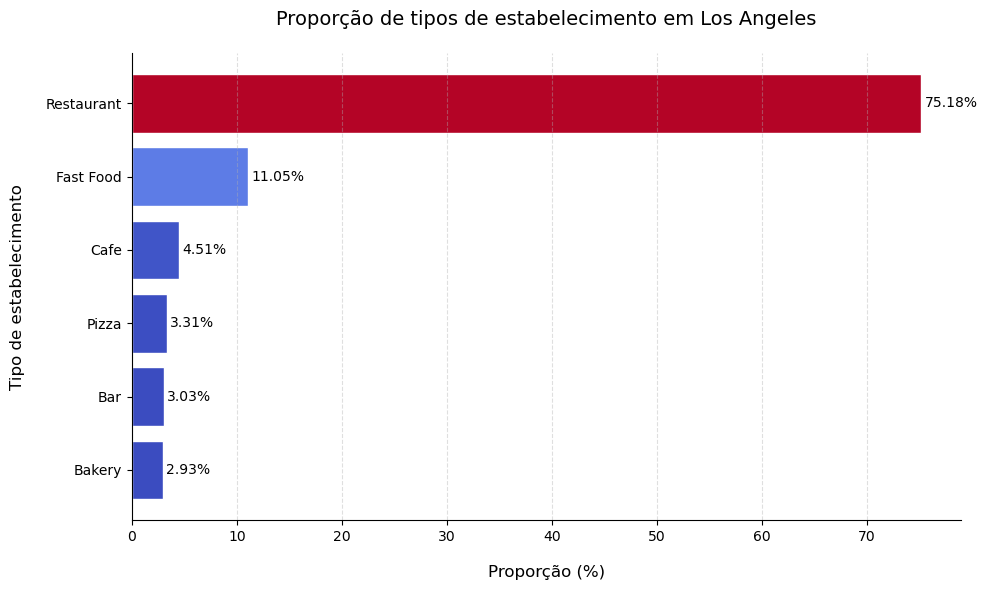

In [120]:
# Gráfico de barras horizontal — proporcões por tipo de estabelecimento
# Escolha: gráfico de barras horizontais é mais legível que pizza quando há
# múltiplas categorias, evitando distorções visuais entre fatias pequenas.

fig, ax = plt.subplots(figsize=(10, 6))

norm = plt.Normalize(type_proportions.values.min(), type_proportions.values.max())
bar_colors = [plt.cm.coolwarm(norm(v)) for v in type_proportions.values]
bars = ax.barh(
    type_proportions.index,  # nomes dos tipos → eixo Y
    type_proportions.values,  # percentuais → eixo X
    color=bar_colors,
    edgecolor='white'
)

# Rótulos de valor ao lado de cada barra
for bar, value in zip(bars, type_proportions.values):
    ax.text(
        value + 0.3,               # posição X: logo após o fim da barra
        bar.get_y() + bar.get_height() / 2,  # posição Y: centro vertical da barra
        f'{value}%',
        va='center',               # alinhamento vertical centralizado
        fontsize=10
    )

ax.set_title('Proporção de tipos de estabelecimento em Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Proporção (%)', fontsize=12, labelpad=15)
ax.set_ylabel('Tipo de estabelecimento', fontsize=12, labelpad=15)
ax.invert_yaxis()  # inverte o eixo Y para o maior valor ficar no topo
ax.grid(axis='x', linestyle='--', alpha=0.4)  
ax.spines[['top', 'right']].set_visible(False)  # remove as bordas superior e direita do gráfico (visual mais limpo)

plt.tight_layout()
plt.show()

### Conclusão

- Os restaurantes representam a grande maioria dos estabelecimentos de alimentação em Los Angeles, seguidos de fast food. Os demais tipos (cafeterias, padarias, bares, etc.) têm participação significativamente menor. Isso indica um mercado dominado por formatos tradicionais de restaurante.


### Proporções de estabelecimentos de rede e independentes


In [53]:
# Calculando proporção de rede vs independente
chain_counts = rest['chain'].value_counts()
chain_labels = chain_counts.index.map({True: 'Rede', False: 'Independente'})  # .map(): substitui cada valor do índice pelo texto correspondente
chain_proportions = (chain_counts / len(rest) * 100).round(2)

print('Proporção → rede vs independente (%):')
for label, value in zip(chain_labels, chain_proportions.values):  # zip(): combina dois iteráveis em pares — a cada iteração, label e value avançam juntos
    print(f'  {label}: {value}%')

Proporção → rede vs independente (%):
  Independente: 61.9%
  Rede: 38.1%


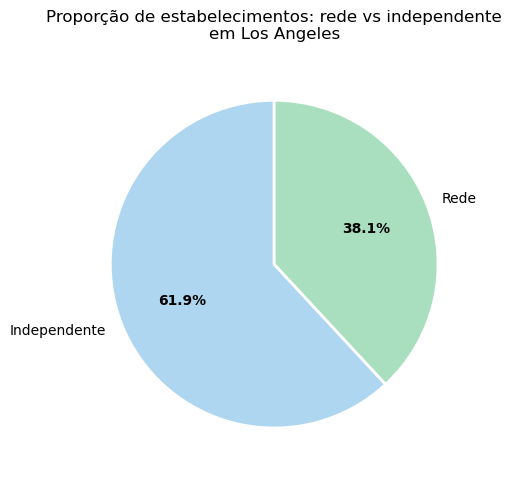

In [54]:
# Gráfico de pizza — rede vs independente
# Escolha: apenas 2 categorias tornam o gráfico de pizza ideal aqui,
# pois a comparação de proporção entre dois grupos é clara e sem distorção.

fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie( # retorna 3 objetos, variáveis, para personalizar o gráfico
    chain_proportions.values,
    labels=chain_labels,
    autopct='%1.1f%%', # formatando o texto automaticamente dentro das fatias
    startangle=90,
    colors=['#AED6F1', '#A9DFBF'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # propriedades visuais das fatias, adicionando uma borda branca entre elas
)

# Ajustando o estilo dos textos
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Proporção de estabelecimentos: rede vs independente\nem Los Angeles', fontsize=12, pad=15)

plt.tight_layout()
plt.show()


### Conclusão

- A maioria dos estabelecimentos em Los Angeles é **independente**, evidenciando um mercado com forte presença de negócios locais. Ainda assim, os estabelecimentos de rede representam uma parcela expressiva — o que é relevante para decisores que avaliam onde investir, já que redes tendem a ter maior poder de marca e padronização.


### Qual tipo de estabelecimento é típico para redes?


In [55]:
# Proporção de cada tipo dentro dos estabelecimentos de REDE
chain_type = (
    rest[rest['chain'] == True]['object_type']  # filtra só as linhas onde chain é True
    .value_counts(normalize=True)               # normalize=True: retorna proporções (0 a 1) em vez de contagens brutas
    .mul(100)                                   # .mul(100): multiplica toda a Series por 100 → converte para percentual
    .round(2)
)

# Proporção de cada tipo dentro dos INDEPENDENTES (para comparação)
indep_type = (
    rest[rest['chain'] == False]['object_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Consolidando em um DataFrame para visualização comparativa
comparison = pd.DataFrame({
    'Rede (%)': chain_type,
    'Independente (%)': indep_type
}).fillna(0)  

print(comparison)


             Rede (%)  Independente (%)
object_type                            
Bakery           7.70              0.00
Bar              2.09              3.60
Cafe             7.24              2.83
Fast Food       16.46              7.72
Pizza            4.16              2.78
Restaurant      62.35             83.07


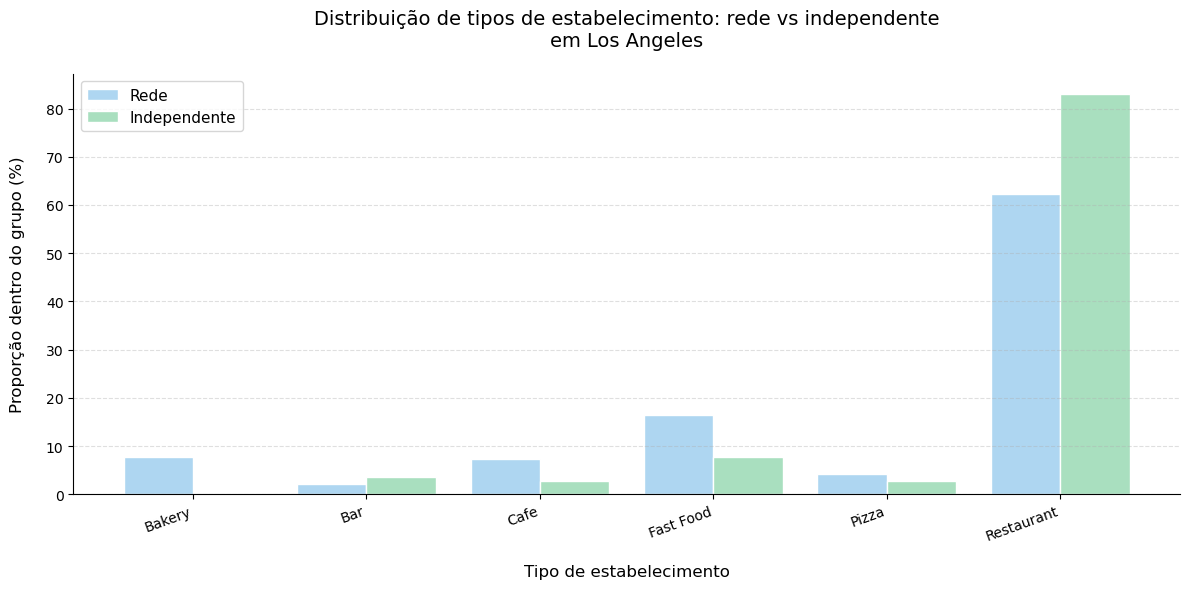

In [67]:
# Gráfico de barras agrupadas — tipo de estabelecimento por rede vs independente
# Escolha: barras agrupadas permitem comparar as duas categorias lado a lado
# para cada tipo de estabelecimento, revelando onde cada grupo é dominante.

x = range(len(comparison.index))  # sequência numérica 0,1,2... — posições no eixo X para cada tipo
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

bars_chain = ax.bar(
    [i - width / 2 for i in x],  # list comprehension: desloca cada posição X para a ESQUERDA em width/2 → barra da rede
    comparison['Rede (%)'],
    width=width,
    label='Rede',
    color='#AED6F1',
    edgecolor='white'
)
bars_indep = ax.bar(
    [i + width / 2 for i in x],  # desloca para a DIREITA em width/2 → barra dos independentes (ficam lado a lado)
    comparison['Independente (%)'],
    width=width,
    label='Independente',
    color='#A9DFBF',
    edgecolor='white'
)

ax.set_xticks(list(x))  # define onde os ticks do eixo X ficam (nas posições numéricas)
ax.set_xticklabels(comparison.index, rotation=20, ha='right', fontsize=10)  # substitui os números pelos nomes dos tipos
ax.set_title('Distribuição de tipos de estabelecimento: rede vs independente\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Tipo de estabelecimento', fontsize=12, labelpad=15)
ax.set_ylabel('Proporção dentro do grupo (%)', fontsize=12, labelpad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)  # remove bordas superior e direita

plt.tight_layout()
plt.show()


### Conclusão

- O **fast food** é o tipo de estabelecimento mais característico das redes — sua proporção dentro do grupo de redes é significativamente maior do que entre os independentes. Isso faz sentido: o modelo de franquia e rede é naturalmente compatível com operações padronizadas e de alto volume, que é a essência do fast food.
- Os **restaurantes** dominam entre os independentes, o que reforça que o formato tradicional de restaurante ainda é o principal veículo dos negócios locais em Los Angeles.


### O que caracteriza redes: muitos estabelecimentos com poucos assentos ou poucos estabelecimentos com muitos assentos?


In [57]:
# Estatísticas descritivas da coluna 'number' (assentos) por grupo
# A coluna 'number' representa a capacidade de assentos de cada estabelecimento
seats_stats = rest.groupby('chain')['number'].agg(['count', 'mean', 'median', 'std'])

# Renomeando índice e colunas para leitura mais clara
seats_stats.index = seats_stats.index.map({True: 'Rede', False: 'Independente'})
seats_stats.columns = ['Qtd. estabelecimentos', 'Média assentos', 'Mediana assentos', 'Desvio padrão']
seats_stats = seats_stats.round(1)

print(seats_stats)


              Qtd. estabelecimentos  Média assentos  Mediana assentos  \
chain                                                                   
Independente                   5972            46.2              28.0   
Rede                           3676            39.7              25.0   

              Desvio padrão  
chain                        
Independente           49.9  
Rede                   43.4  


/var/folders/fs/3hy1lgmd3p79yftgf7gp8gqh0000gn/T/ipykernel_45956/1108807410.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


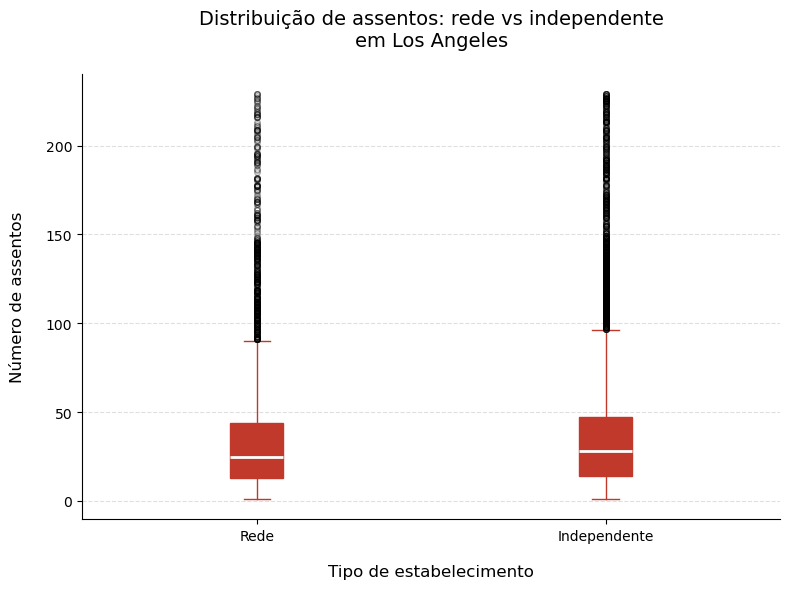

In [58]:
# Gráfico de boxplot — distribuição de assentos por grupo (rede vs independente)
# Escolha: boxplot é ideal para comparar distribuições, mostrando mediana,
# dispersão e outliers — essencial para entender 'muitos com poucos' vs 'poucos com muitos'

fig, ax = plt.subplots(figsize=(8, 6))

# Separando os dados de cada grupo
data_chain = rest[rest['chain'] == True]['number']
data_indep = rest[rest['chain'] == False]['number']

ax.boxplot(
    [data_chain, data_indep],
    labels=['Rede', 'Independente'],
    patch_artist=True,                        # patch_artist=True: preenche as caixas com cor (padrão é sem preenchimento)
    boxprops=dict(facecolor='#C0392B', color='#C0392B'),  # cor da caixa
    medianprops=dict(color='white', linewidth=2),          # linha da mediana
    whiskerprops=dict(color='#C0392B'),     # whiskerprops: estilo das linhas que se estendem além da caixa (bigodes)
    capprops=dict(color='#C0392B'),         # capprops: estilo das tampinhas no fim dos bigodes
    flierprops=dict(marker='o', color='#C0392B', alpha=0.3, markersize=4)  # flierprops: estilo dos outliers (pontos fora dos bigodes)
)

ax.set_title('Distribuição de assentos: rede vs independente\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Tipo de estabelecimento', fontsize=12, labelpad=15)
ax.set_ylabel('Número de assentos', fontsize=12, labelpad=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


### Conclusão

- Os dados mostram que redes têm **mediana de 25 assentos** por estabelecimento, contra **28 dos independentes** — ou seja, as unidades de rede são ligeiramente menores em capacidade. Porém, o ponto central da resposta está na **quantidade**: existem **3.676 estabelecimentos de rede** contra **5.972 independentes**, sendo que os independentes são em maior número absoluto mas operam com locais maiores em média.
- A conclusão é que **redes se caracterizam pelo modelo de muitos estabelecimentos com pequeno número de assentos** — consistente com o perfil de fast food identificado na análise anterior, onde a padronização e o alto volume de unidades compensam o tamanho reduzido de cada local.
- O desvio padrão menor das redes (43,4 vs 49,9) reforça isso: os estabelecimentos de rede são mais **homogêneos** em tamanho, enquanto os independentes apresentam maior variação — alguns podem ser pequenos botecos, outros grandes restaurantes.


### Número médio de assentos por tipo de estabelecimento

In [59]:
# Média de assentos por tipo de estabelecimento, ordenada de forma decrescente
avg_seats = (
    rest.groupby('object_type')['number']
    .mean()
    .round(1)
    .sort_values(ascending=False)
)

print('Número médio de assentos por tipo de estabelecimento:')
print(avg_seats.to_string())
print(f'\nTipo com maior média: {avg_seats.idxmax()} ({avg_seats.max()} assentos)')


Número médio de assentos por tipo de estabelecimento:
object_type
Restaurant    48.0
Bar           44.8
Fast Food     31.8
Pizza         28.5
Cafe          25.0
Bakery        21.8

Tipo com maior média: Restaurant (48.0 assentos)


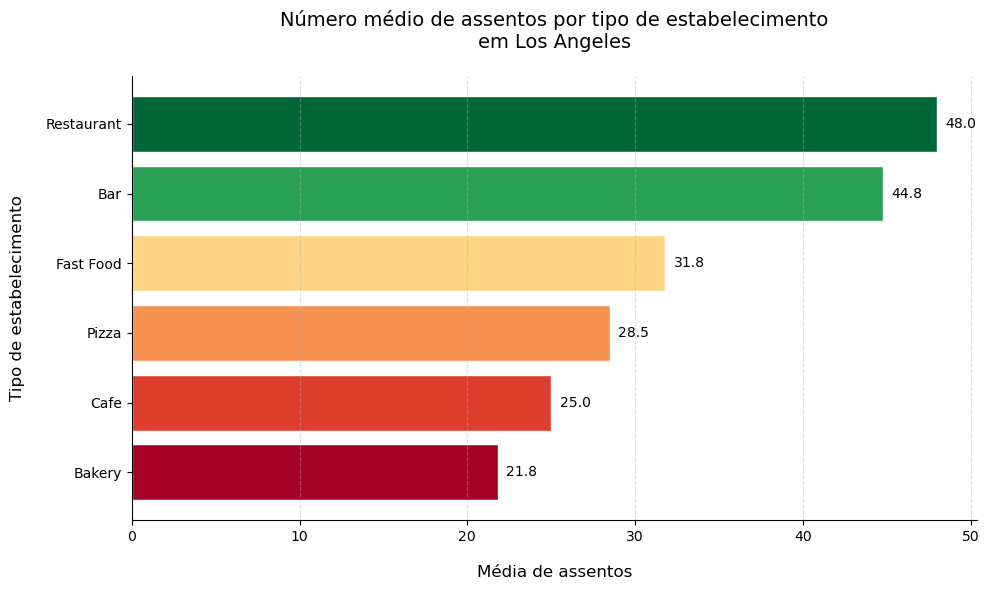

In [106]:
# Gráfico de barras horizontais — média de assentos por tipo de estabelecimento
# Escolha: barras horizontais facilitam a leitura dos rótulos de cada categoria
# e permitem comparar visualmente qual tipo tem maior capacidade média.

fig, ax = plt.subplots(figsize=(10, 6))

vals_desc = avg_seats.values[::-1]
norm = plt.Normalize(vals_desc.min(), vals_desc.max())
bar_colors = [plt.cm.RdYlGn(norm(v)) for v in vals_desc]
bars = ax.barh(
    avg_seats.index[::-1],   # inverte para maior média ficar no topo
    vals_desc,
    color=bar_colors,
    edgecolor='white'
)

# Rótulos de valor ao lado de cada barra
for bar, value in zip(bars, avg_seats.values[::-1]):  # zip(): combina cada barra com seu valor correspondente (ambos já invertidos)
    ax.text(
        value + 0.5,                           # posição X: colocando o texto após o fim da barra para não sobrepor
        bar.get_y() + bar.get_height() / 2,    # posição Y: retorna a coordenada da base da barra; somando metade da altura, o texto fica centralizado verticalmente no meio da barra
        f'{value}',                            # texto exibido: o valor numérico da média de assentos como rótulo
        va='center',
        fontsize=10
    )

ax.set_title('Número médio de assentos por tipo de estabelecimento\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Média de assentos', fontsize=12, labelpad=15)
ax.set_ylabel('Tipo de estabelecimento', fontsize=12, labelpad=15)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)


plt.tight_layout()
plt.show()

### Conclusão

- Em média, os **restaurantes** têm o maior número de assentos entre todos os tipos de estabelecimento em Los Angeles, seguidos de **bares** e **padarias**. Isso faz sentido: restaurantes tradicionais dependem de capacidade de atendimento presencial para geração de receita, enquanto fast foods e cafeterias tendem a operar com espaços menores e maior rotatividade.
- O resultado reforça a análise anterior: as redes, que são dominadas por fast foods, operam com menor capacidade por unidade (menor média de assentos), enquanto os restaurantes independentes — que em sua maioria são do tipo "restaurant" — tendem a ter espaços maiores.


## Trabalhando com os endereços

### Extração do nome da rua

In [61]:
# Extraindo o nome da rua a partir da coluna 'address':
# 1. Remover o número do imóvel (dígitos no início)
# 2. Remover informações de unidade/apartamento no final (STE, UNIT, APT, # ou número solto)
rest['street_name'] = (
    rest['address']
    .str.replace(r'^\d+\s+', '', regex=True)                              # removendo número do imóvel
    .str.replace(r'\s+(?:STE|UNIT|APT|#)\s*\S+.*$', '', regex=True)      # removendo suite/unidade com prefixo
    .str.replace(r'\s+\d+\s*$', '', regex=True)                           # removendo número solto no final
    .str.strip()
)

print('Exemplos de extração:')
print(rest[['address', 'street_name']].head(10).to_string(index=False))

Exemplos de extração:
                        address       street_name
         3708 N EAGLE ROCK BLVD N EAGLE ROCK BLVD
              100 WORLD WAY 120         WORLD WAY
        6801 HOLLYWOOD BLVD 253    HOLLYWOOD BLVD
             1814 W SUNSET BLVD     W SUNSET BLVD
             2100 ECHO PARK AVE     ECHO PARK AVE
            10004 NATIONAL BLVD     NATIONAL BLVD
              100 WORLD WAY 126         WORLD WAY
          3500 W 6TH ST STE 226          W 6TH ST
3027 N SAN FERNANDO RD UNIT 103 N SAN FERNANDO RD
           3707 N CAHUENGA BLVD   N CAHUENGA BLVD


### Dez ruas com o maior número de restaurantes

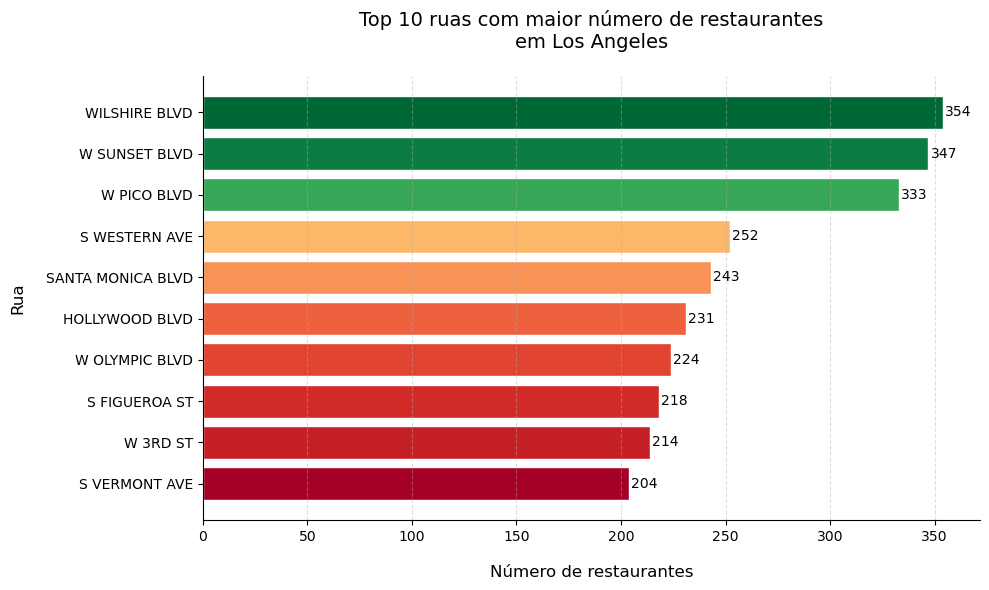

In [89]:
# Top 10 ruas com maior número de restaurantes
top10_streets = (
    rest['street_name']
    .value_counts()
    .head(10)
    .sort_values()   # crescente para ficar maior no topo do gráfico horizontal
)

fig, ax = plt.subplots(figsize=(10, 6))

norm = plt.Normalize(top10_streets.values.min(), top10_streets.values.max())
bar_colors = [plt.cm.RdYlGn(norm(v)) for v in top10_streets.values]
bars = ax.barh(top10_streets.index, top10_streets.values, color=bar_colors, edgecolor='white')

for bar, value in zip(bars, top10_streets.values):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va='center',
        fontsize=10
    )

ax.set_title('Top 10 ruas com maior número de restaurantes\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Número de restaurantes', fontsize=12, labelpad=15)
ax.set_ylabel('Rua', fontsize=12, labelpad=15)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Ruas com apenas um restaurante

In [63]:
# Número de ruas com apenas um restaurante
street_counts = rest['street_name'].value_counts()
single_restaurant_streets = (street_counts == 1).sum()

print(f'Total de ruas únicas: {len(street_counts)}')
print(f'Ruas com apenas 1 restaurante: {single_restaurant_streets}')
print(f'Proporção: {single_restaurant_streets / len(street_counts) * 100:.1f}% das ruas listadas possuem apenas um restaurante')

Total de ruas únicas: 1294
Ruas com apenas 1 restaurante: 822
Proporção: 63.5% das ruas listadas possuem apenas um restaurante


### Distribuição de assentos nas ruas com muitos restaurantes

In [64]:
# Estatísticas de assentos por rua do top 10
top10_names = top10_streets.index.tolist()  # nomes das 10 ruas com mais restaurantes

top10_data = rest[rest['street_name'].isin(top10_names)]

seats_by_street = (
    top10_data.groupby('street_name')['number']
    .agg(restaurantes='count', media='mean', mediana='median', desvio_padrao='std')
    .round(1)
    .sort_values('restaurantes', ascending=False)
)

print('Distribuição de assentos nas 10 ruas com mais restaurantes:')
print(seats_by_street.to_string())

Distribuição de assentos nas 10 ruas com mais restaurantes:
                   restaurantes  media  mediana  desvio_padrao
street_name                                                   
WILSHIRE BLVD               354   53.3     36.0           51.9
W SUNSET BLVD               347   48.9     34.0           50.2
W PICO BLVD                 333   39.7     26.0           41.2
S WESTERN AVE               252   41.8     28.0           42.3
SANTA MONICA BLVD           243   36.1     22.0           41.6
HOLLYWOOD BLVD              231   53.9     33.0           56.0
W OLYMPIC BLVD              224   49.9     28.0           56.3
S FIGUEROA ST               218   47.2     25.5           49.3
W 3RD ST                    214   38.3     26.0           38.4
S VERMONT AVE               204   44.0     28.0           47.8


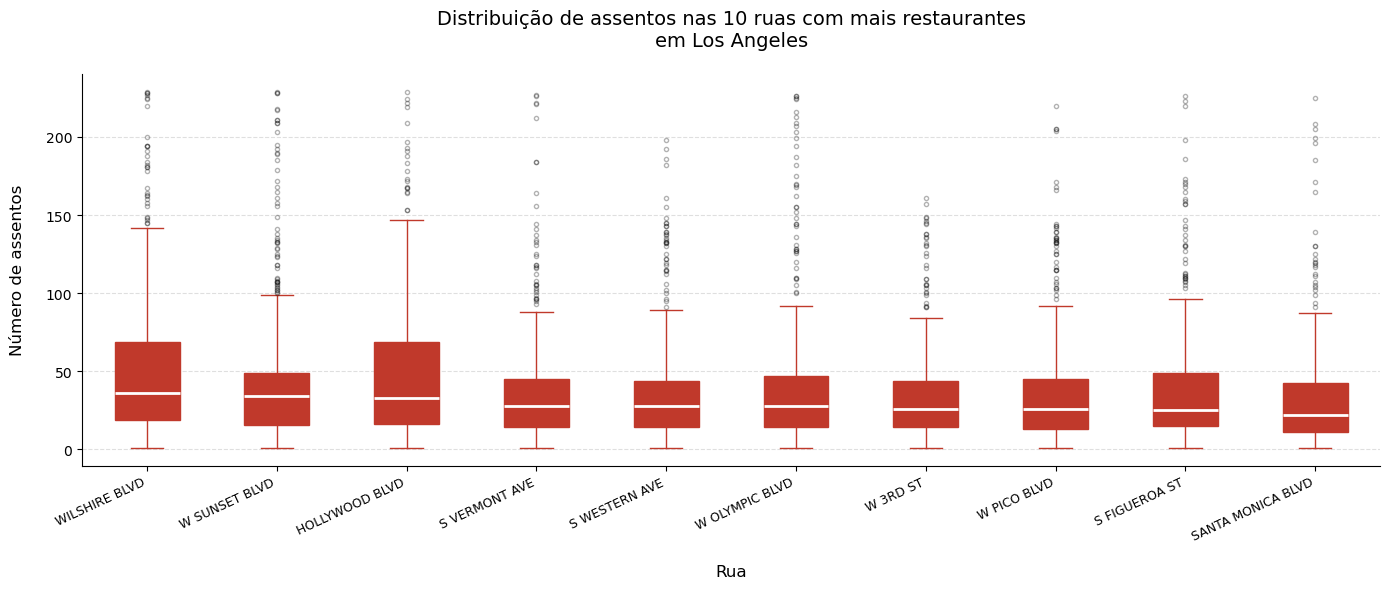

In [ ]:
# Boxplot — distribuição de assentos por rua (top 10)
# Ordenado pela mediana para facilitar comparação visual
order = (
    top10_data.groupby('street_name')['number']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))

data_by_street = [top10_data[top10_data['street_name'] == s]['number'].values for s in order]
# list comprehension: para cada rua em 'order', filtra as linhas do DataFrame correspondentes a essa rua
# e extrai os valores da coluna 'number' (assentos) como array NumPy.
# O resultado é uma lista de arrays — um por rua — no formato que o boxplot espera para criar uma caixa por grupo.

bp = ax.boxplot(
    data_by_street,
    tick_labels=order,
    patch_artist=True,
    boxprops=dict(facecolor='#C0392B', color='#C0392B'),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#C0392B'),
    capprops=dict(color='#C0392B'),
    flierprops=dict(marker='o', color='#C0392B', alpha=0.3, markersize=3)
)

ax.set_title('Distribuição de assentos nas 10 ruas com mais restaurantes\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Rua', fontsize=12, labelpad=15)
ax.set_ylabel('Número de assentos', fontsize=12, labelpad=15)
ax.set_xticklabels(order, rotation=25, ha='right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusão

- **Medianas baixas e consistentes**: a mediana de assentos nas ruas com mais restaurantes gira em torno de **22 a 36 assentos** em todas elas, indicando que a maioria dos estabelecimentos é de pequeno porte, independente da rua.
- **Alta presença de outliers**: todas as ruas apresentam muitos pontos acima do bigode superior — estabelecimentos com 150–225 assentos. Isso mostra que convivem, nas mesmas ruas, pequenos botecos e grandes restaurantes.
- **Wilshire Blvd e Hollywood Blvd** se destacam com as medianas mais altas (~36 e ~33 assentos) e maior variação (desvio padrão > 50), sugerindo perfil mais diversificado — de fast foods pequenos a restaurantes maiores.
- **Santa Monica Blvd e W Pico Blvd** têm as medianas mais baixas (~22 e ~26 assentos) e desvio padrão menor, indicando predominância de estabelecimentos menores e mais homogêneos — perfil mais voltado a fast food e consumo rápido.